# Demo 1: Build a serverless image-analysis pipeline

In this demo, an image upload starts an event-driven AWS workflow:

**Amazon S3 → AWS Lambda → Amazon Rekognition → Amazon DynamoDB → Amazon CloudWatch**

The image is uploaded to S3. S3 automatically invokes a Lambda function, which sends the image to Rekognition for analysis. Lambda stores the useful parts of the response—such as detected objects, confidence scores, text, faces, emotions, and celebrity matches—in DynamoDB. CloudWatch records the Lambda invocation and the application's completion log.

This is a serverless application: we build the event flow and application logic, while AWS operates the compute infrastructure and supplies the trained computer-vision models.

## Learning goals and architecture

By the end of this notebook, you should be able to explain how an object-created event in S3 can trigger a serverless workflow, how an application consumes a managed AI service, and how results and operational evidence are stored.

The AWS services have distinct responsibilities:

- **Amazon S3** stores the source images and acts as the event source.
- **AWS Lambda** runs our Python application code when an image is uploaded. No server needs to be provisioned or managed.
- **Amazon Rekognition** provides pretrained computer-vision APIs. This demo uses label, text, face, emotion, and celebrity detection; it does not train a model.
- **Amazon DynamoDB** stores one analysis record per uploaded image in a serverless NoSQL table.
- **Amazon CloudWatch Logs** records Lambda runtime events and the application's `analysis_complete` message.
- **AWS Serverless Application Model (SAM) and AWS CloudFormation** define and deploy the bucket, function, table, permissions, and event connection as infrastructure as code.

A useful boundary to notice is that the notebook does not call Rekognition directly. Its only inference action is uploading an image. The S3 event causes the deployed application to do the remaining work.

In [ ]:
import json
import os
import time
from datetime import datetime, timezone
from pathlib import Path

import boto3
from IPython.display import Image, JSON, display

REGION = "ap-southeast-2"
STACK_NAME = "cits5503-demo1"
UPLOAD_KEY = "uploads/car.jpg"
SEINFELD_KEY = "uploads/seinfeld.jpg"
PROFILE = os.environ.get("AWS_PROFILE")  # Set this in your terminal if needed.

# This lets the notebook work whether Jupyter starts here or at the repository root.
def locate_demo_dir():
    candidates = [
        Path.cwd(),
        Path.cwd() / "demo1_rekognition_pipeline",
        Path.cwd() / "demo" / "demo1_rekognition_pipeline",
    ]
    for candidate in candidates:
        if (candidate / "template.yaml").exists():
            return candidate.resolve()
    raise RuntimeError("Open this notebook from its folder or the repository root.")

DEMO_DIR = locate_demo_dir()
DEMO_ROOT = DEMO_DIR.parent

# Reuse one configured session so every AWS client uses the same account and region.
session = boto3.Session(profile_name=PROFILE, region_name=REGION)

DEMO_DIR

PosixPath('/Users/larryhh/Documents/UWA/CITS5503/demo/demo1_rekognition_pipeline')

## 1. Deployment prerequisite

The infrastructure must exist before the notebook can upload an image. From the repository's `demo/` directory, run `./manage_demo.sh --demo 1 --action deploy --profile cits5503` (omit `--profile` if you use the default AWS profile).

SAM and CloudFormation create the S3 bucket, DynamoDB table, Lambda function, IAM permissions, and S3 notification that invokes Lambda. Deployment is kept outside the notebook so that the notebook focuses on using and observing the event-driven application. After changing the Lambda code, use the script's `redeploy` action to build and update the existing stack.

In [3]:
profile_option = f" --profile {PROFILE}" if PROFILE else ""
print("Required deployment command (run from a terminal):")
print(f"cd {DEMO_DIR.parent} && ./manage_demo.sh --demo 1 --action deploy{profile_option}")

Deployment is a Terminal step. Run this before the notebook:
cd /Users/larryhh/Documents/UWA/CITS5503/demo && ./manage_demo.sh --demo 1 --action deploy


## 2. Preflight

Before using AWS resources, confirm which account and region the SDK will access. This cell uses AWS Security Token Service (STS) to show the current identity, then asks CloudFormation for the deployed stack. It is a read-only check and does not create resources.

In [2]:
identity = session.client("sts").get_caller_identity()
cloudformation = session.client("cloudformation")
cloudformation.describe_stacks(StackName=STACK_NAME)
print(f"Account: {identity['Account']}\nARN: {identity['Arn']}\nRegion: {REGION}\nPipeline stack: {STACK_NAME}")

Account: 489389878001
ARN: arn:aws:iam::489389878001:user/larry.huynh@uwa.edu.au
Region: ap-southeast-2
Pipeline stack: cits5503-demo1


## 3. Read the generated resource names

CloudFormation generates physical names for the resources to avoid naming collisions. This cell reads the stack outputs and assigns the deployed bucket, table, and function names to variables used by the rest of the notebook.

In [4]:
stack = cloudformation.describe_stacks(StackName=STACK_NAME)["Stacks"][0]
# Convert CloudFormation's list of key/value objects into an easier lookup dictionary.
outputs = {item["OutputKey"]: item["OutputValue"] for item in stack["Outputs"]}

BUCKET = outputs["UploadBucketName"]
TABLE = outputs["LabelsTableName"]
FUNCTION = outputs["FunctionName"]
display(JSON({"bucket": BUCKET, "table": TABLE, "function": FUNCTION}))

<IPython.core.display.JSON object>

## 4. How SAM creates and connects the pipeline

**AWS Serverless Application Model (SAM)** is a framework for defining and deploying serverless applications. In practical terms, it tells AWS which cloud resources to create and how to connect them, so you do not have to configure each one manually. A SAM template is a CloudFormation template with shorter resource types for common serverless components. In this project, [`template.yaml`](template.yaml) is the infrastructure blueprint.

SAM is involved at **deployment time**:

1. `sam build` prepares the Lambda source code and deployment artefacts.
2. `sam deploy` sends the generated CloudFormation template and artefacts to AWS.
3. CloudFormation creates or updates the S3 bucket, Lambda function, DynamoDB table, IAM permissions, and S3 notification.

SAM does not process an image itself. After deployment, the AWS resources communicate directly whenever an upload occurs.

The start of `template.yaml` enables the SAM extensions:

```yaml
Transform: AWS::Serverless-2016-10-31
```

The Lambda resource identifies the source directory and the Python function that AWS should call. `app.lambda_handler` means the `lambda_handler` function in `src/app.py`:

```yaml
ImageAnalysisFunction:
  Type: AWS::Serverless::Function
  Properties:
    CodeUri: src/
    Handler: app.lambda_handler
    Environment:
      Variables:
        TABLE_NAME: !Ref LabelsTable
```

`!Ref LabelsTable` inserts the generated DynamoDB table name into the Lambda environment. This lets the Python code find the table without hard-coding a physical resource name.

### The S3 event connection

The `NotificationConfiguration` on the bucket connects object-created events to the Lambda function. The prefix filter means that only keys beginning with `uploads/` start the analysis:

```yaml
NotificationConfiguration:
  LambdaConfigurations:
    - Event: s3:ObjectCreated:*
      Function: !GetAtt ImageAnalysisFunction.Arn
      Filter:
        S3Key:
          Rules:
            - Name: prefix
              Value: !Ref UploadPrefix
```

A separate `AWS::Lambda::Permission` resource permits the S3 service to invoke the function:

```yaml
ImageAnalysisFunctionUploadPermission:
  Type: AWS::Lambda::Permission
  Properties:
    Action: lambda:InvokeFunction
    FunctionName: !Ref ImageAnalysisFunction
    Principal: s3.amazonaws.com
```

The Lambda role also receives permission to read uploaded objects, call the selected Rekognition APIs, and write to DynamoDB. These permissions are necessary even though the resources belong to the same AWS account.

```mermaid
flowchart LR
    A[Notebook] -->|PutObject| B[S3 uploads/ prefix]
    B -->|ObjectCreated event| C[Lambda app.lambda_handler]
    C -->|Image stored in S3| D[Rekognition]
    D -->|Labels, text, faces, celebrities| C
    C -->|PutItem| E[DynamoDB]
    C -->|Application and runtime logs| F[CloudWatch Logs]
```

At runtime, the sequence is therefore: upload the image, receive the S3 event, run Lambda, call Rekognition, store the selected result, and emit a completion log. The notebook later reads DynamoDB and CloudWatch to observe those asynchronous steps.

## 5. Upload an image and trigger the pipeline

The upload is the inference request from the notebook's point of view. The object is written under the bucket's `uploads/` prefix, which matches the S3 notification configured in the SAM template. S3 then invokes Lambda asynchronously.

Lambda reads the object from S3, calls Rekognition, and writes the selected results to DynamoDB. Because this happens asynchronously, the upload call can finish before the analysis record appears.

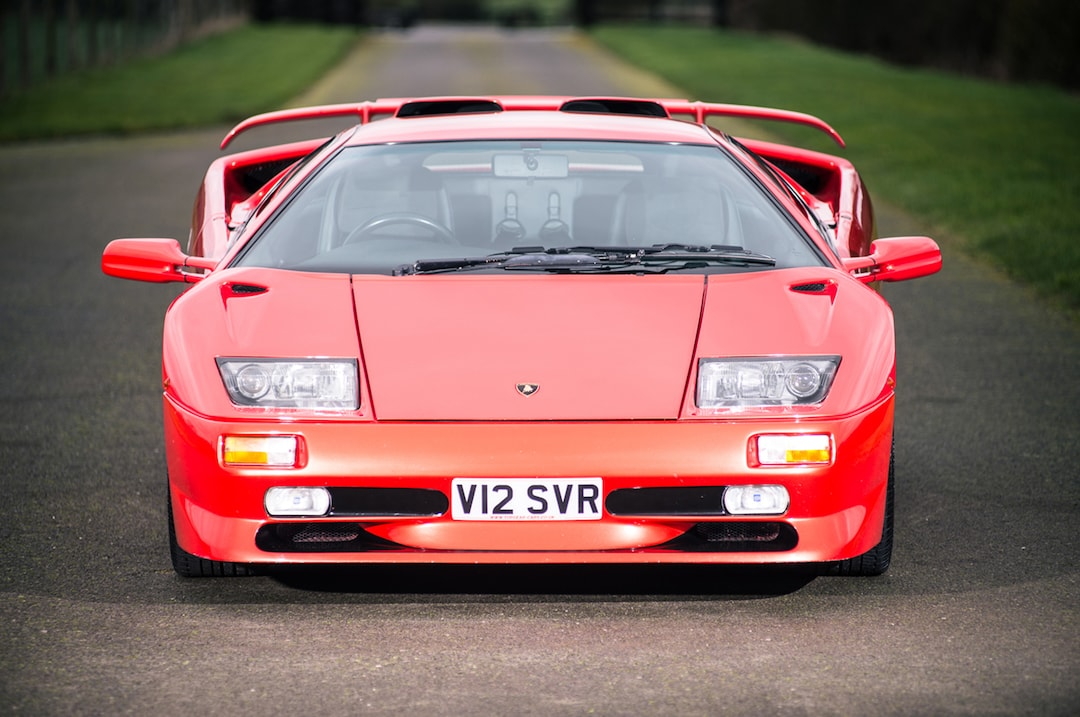

Uploaded s3://cits5503-demo1-uploadbucket-pdasgnwiwbzw/uploads/car.jpg


In [5]:
car_path = DEMO_ROOT / "images" / "car.jpg"
if not car_path.exists():
    raise FileNotFoundError("Could not find car.jpg. Add it to demo/images/.")
display(Image(filename=str(car_path), width=800))

s3 = session.client("s3")
# Save the time so later cells can distinguish this run from an older table row.
upload_started_at = datetime.now(timezone.utc)
# Uploading is the only action needed: S3 invokes Lambda asynchronously.
s3.upload_file(str(car_path), BUCKET, UPLOAD_KEY)
print(f"Uploaded s3://{BUCKET}/{UPLOAD_KEY}")

### Process a second image through the same pipeline

The second image follows exactly the same route and requires no new infrastructure. Rekognition's response depends on the image content: the car image is useful for object and text detection, while the Seinfeld image demonstrates face attributes, emotions, and celebrity recognition.

Both uploads illustrate an important property of event-driven systems: the producer only writes an object to S3 and does not need to know how the downstream analysis is implemented.

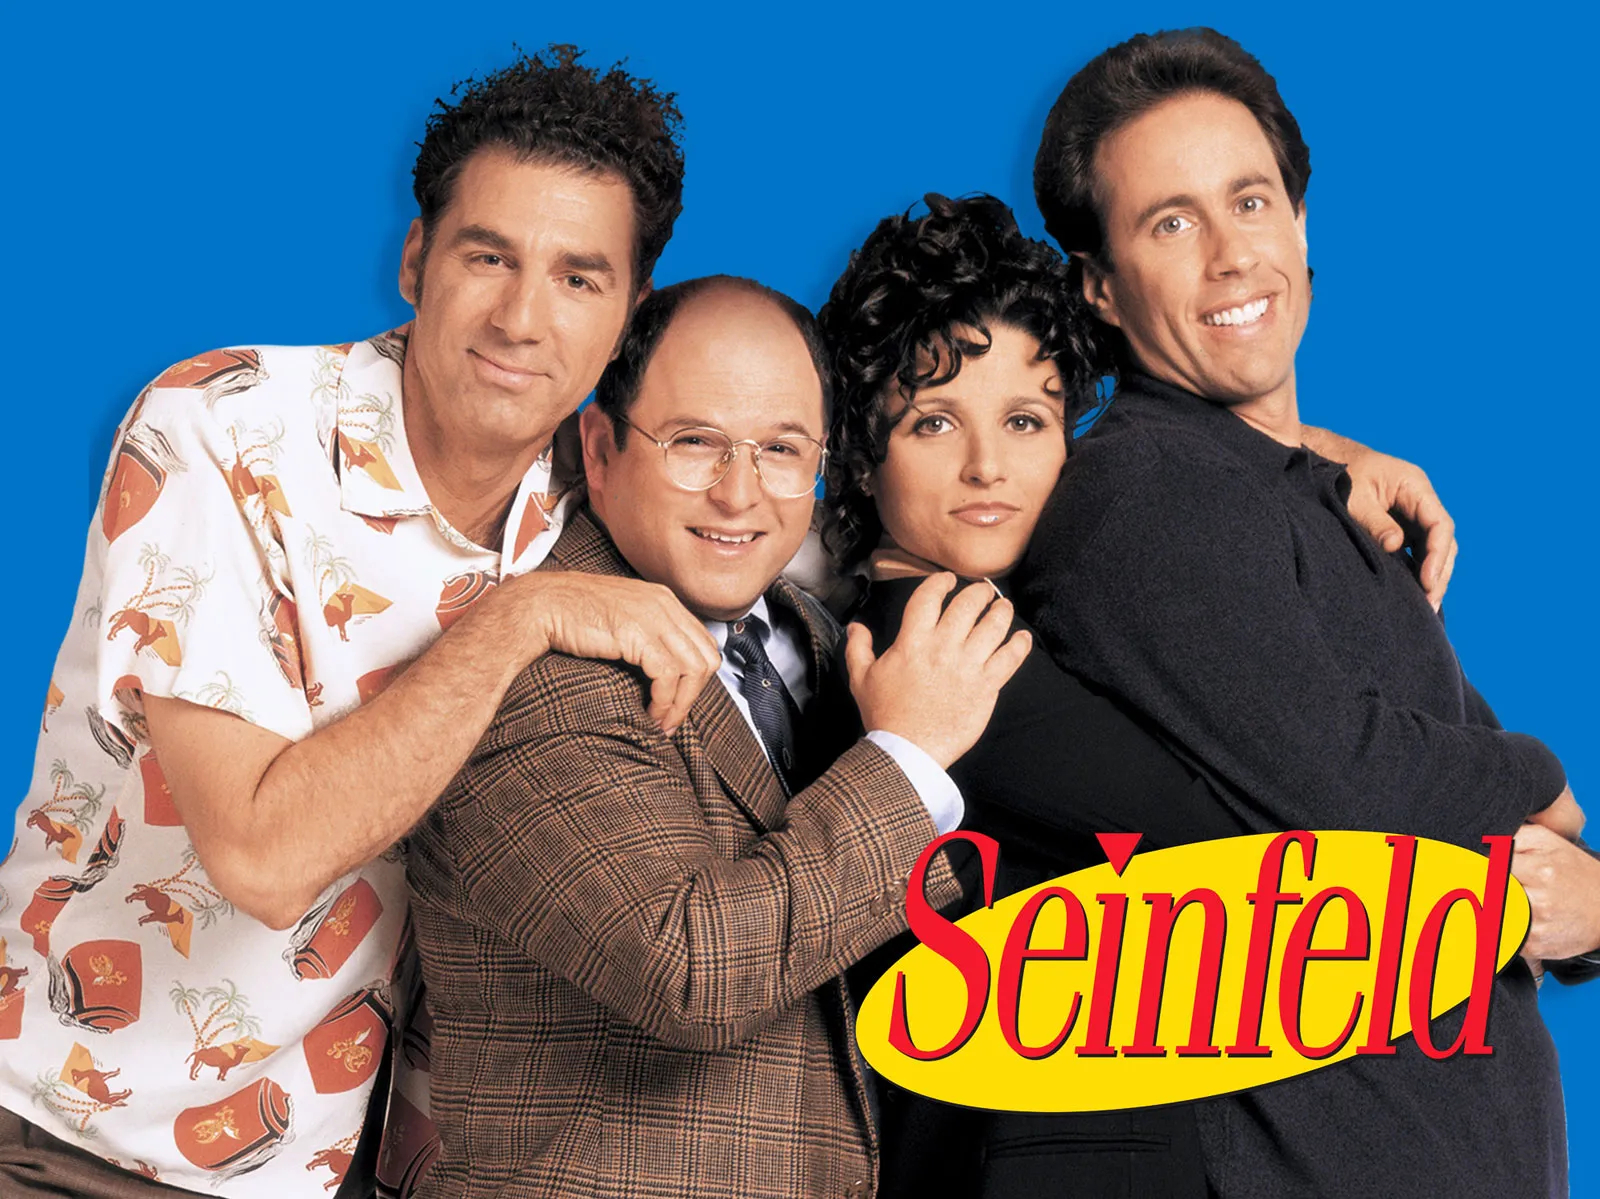

Uploaded s3://cits5503-demo1-uploadbucket-pdasgnwiwbzw/uploads/seinfeld.jpg


In [6]:
seinfeld_path = DEMO_ROOT / "images" / "seinfeld.jpg"
display(Image(filename=str(seinfeld_path), width=800))
s3.upload_file(str(seinfeld_path), BUCKET, SEINFELD_KEY)
print(f"Uploaded s3://{BUCKET}/{SEINFELD_KEY}")

## 6. Inspect the results stored by the workflow

S3 invokes Lambda asynchronously, so this cell polls DynamoDB for up to 20 seconds and waits for a record whose processing timestamp is newer than the upload. This prevents an older record for the same object key from being mistaken for the current result.

DynamoDB contains the application-specific representation chosen by the Lambda code. It includes labels and confidence scores, detected text, face attributes and bounding boxes, and celebrity matches. Numeric values are returned by the DynamoDB SDK as `Decimal`, so the display conversion below turns them into JSON-compatible strings.

In [ ]:
dynamodb = session.resource("dynamodb")
table = dynamodb.Table(TABLE)
# The fallback also allows this section to work after restarting the notebook kernel.
analysis_started_at = globals().get("upload_started_at", datetime.min.replace(tzinfo=timezone.utc))

def wait_for_analysis(image_key):
    # S3 and Lambda are asynchronous, so poll briefly instead of assuming the row exists.
    for _ in range(20):  # Try for up to 20 seconds.
        item = table.get_item(Key={"image_key": image_key}).get("Item")
        if item and datetime.fromisoformat(item["processed_at"]) >= analysis_started_at:
            return item
        time.sleep(1)
    raise RuntimeError(f"No DynamoDB item appeared for {image_key}. Run the log cell to diagnose Lambda.")

results = {
    "car": wait_for_analysis(UPLOAD_KEY),
    "seinfeld": wait_for_analysis(SEINFELD_KEY),
}

In [30]:
# Convert DynamoDB Decimal values to strings so IPython's JSON viewer can render them.
display(JSON(json.loads(json.dumps(results["car"], default=str)), expanded=True))

<IPython.core.display.JSON object>

In [31]:
# Convert DynamoDB Decimal values to strings so IPython's JSON viewer can render them.
display(JSON(json.loads(json.dumps(results["seinfeld"], default=str)), expanded=True))

<IPython.core.display.JSON object>

## 7. Render the analysis on the images

Raw JSON is useful for inspection, but spatial predictions are easier to understand when drawn on the source image. The shared `render_image_analysis` function converts Rekognition's proportional bounding boxes into image pixel coordinates.

The car view marks detected text in blue, including the licence plate when recognised. The Seinfeld views separately show the strongest detected emotion for each face in red and celebrity matches in green. Separating the views keeps overlapping annotations readable while using the same rendering function and data model.

In [50]:
from PIL import Image as PILImage, ImageDraw, ImageFont

FONT = ImageFont.load_default(size=24)

def render_image_analysis(image_path, analysis, annotations):
    image = PILImage.open(image_path).convert("RGB")
    draw = ImageDraw.Draw(image)
    width, height = image.size

    def pixels(box):
        # Rekognition returns proportional coordinates; Pillow draws in pixels.
        return (
            int(float(box["left"]) * width),
            int(float(box["top"]) * height),
            int((float(box["left"]) + float(box["width"])) * width),
            int((float(box["top"]) + float(box["height"])) * height),
        )

    if "faces" in annotations:
        for index, face in enumerate(analysis.get("face_boxes", []), start=1):
            box = pixels(face["bounding_box"])
            draw.rectangle(box, outline="red", width=4)
            draw.text((box[0], max(0, box[1] - 28)), f"Face {index}", fill="red", font=FONT)

    if "text" in annotations:
        for text in analysis.get("text_detections", []):
            if "bounding_box" not in text:
                continue
            box = pixels(text["bounding_box"])
            draw.rectangle(box, outline="blue", width=4)
            draw.text((box[0], max(0, box[1] - 28)), text["text"], fill="blue", font=FONT)

    if "emotions" in annotations:
        for index, face in enumerate(analysis.get("face_analysis", []), start=1):
            box = pixels(face["bounding_box"])
            emotions = face.get("emotions", [])
            label = f"Face {index}"
            if emotions:
                strongest = max(emotions, key=lambda emotion: float(emotion["confidence"]))
                label += f": {strongest['type'].title()} ({float(strongest['confidence']):.0f}%)"
            draw.rectangle(box, outline="red", width=4)
            draw.text((box[0], max(0, box[1] - 28)), label, fill="white", font=FONT)

    if "celebrities" in annotations:
        for celebrity in analysis.get("celebrity_matches", []):
            if "bounding_box" not in celebrity:
                print(f"No bounding box stored for {celebrity['name']}; redeploy and upload again.")
                continue
            box = pixels(celebrity["bounding_box"])
            draw.rectangle(box, outline="lime", width=4)
            draw.text((box[0], max(0, box[1] - 28)), celebrity["name"], fill="lime", font=FONT)

    display(Image(data=image_to_bytes(image), format="png", width=800))

def image_to_bytes(image):
    import io
    buffer = io.BytesIO()
    image.save(buffer, format="PNG")
    return buffer.getvalue()

def print_car_summary(analysis):
    print("Detected labels:")
    labels = analysis.get("labels", [])
    if labels:
        for label in labels:
            print(f"{label['name']}: {float(label['confidence']):.2f}%")
    else:
        print("No labels detected.")

    print("\nDetected text:")
    detections = analysis.get("text_detections", [])
    if detections:
        for detection in detections:
            print(f"{detection['text']}: {float(detection['confidence']):.2f}%")
    else:
        print("No text detected.")

def print_face_summary(analysis):
    faces = analysis.get("face_analysis", [])
    if not faces:
        print("No face details stored; redeploy and upload the image again.")
        return

    for index, face in enumerate(faces, start=1):
        print(f"FACE {index}")
        emotions = face.get("emotions", [])
        emotion_text = ", ".join(
            f"{emotion['type']} ({float(emotion['confidence']):.2f}%)"
            for emotion in emotions
        )
        print(f"Emotions: {emotion_text or 'not available'}")
        print("---")

Car: detected text / licence plate
Detected labels:
Bumper: 100.00%
Transportation: 100.00%
Vehicle: 100.00%
Car: 99.61%
Chair: 88.24%
Furniture: 88.24%

Detected text:
VI2 SVR: 96.54%


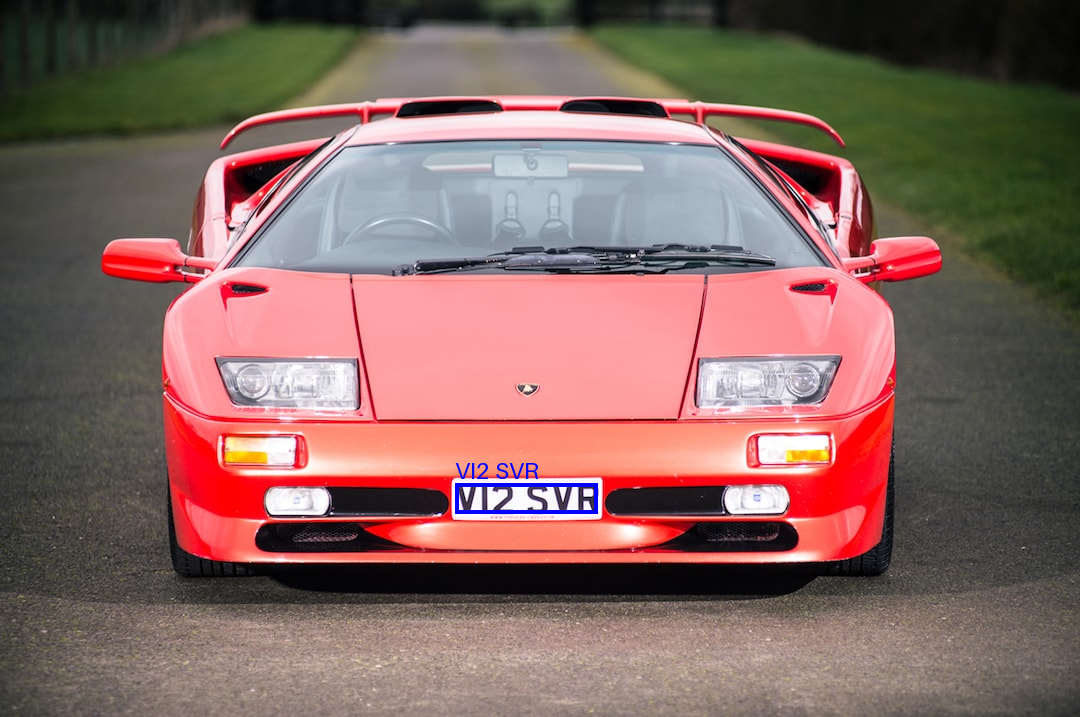

In [51]:
print("Car: detected text / licence plate")
print_car_summary(results["car"])
render_image_analysis(car_path, results["car"], annotations=("text",))

Seinfeld: emotion recognition
FACE 1
Emotions: HAPPY (99.67%), CONFUSED (0.06%), SURPRISED (0.01%), CALM (0.00%), ANGRY (0.00%), FEAR (0.00%), DISGUSTED (0.00%), SAD (0.00%)
---
FACE 2
Emotions: HAPPY (97.07%), CALM (0.76%), SURPRISED (0.12%), DISGUSTED (0.03%), CONFUSED (0.01%), SAD (0.00%), ANGRY (0.00%), FEAR (0.00%)
---
FACE 3
Emotions: HAPPY (99.35%), SURPRISED (0.15%), CALM (0.01%), CONFUSED (0.01%), FEAR (0.00%), ANGRY (0.00%), DISGUSTED (0.00%), SAD (0.00%)
---
FACE 4
Emotions: CALM (91.00%), HAPPY (1.70%), SURPRISED (0.61%), CONFUSED (0.45%), SAD (0.10%), DISGUSTED (0.04%), ANGRY (0.02%), FEAR (0.00%)
---


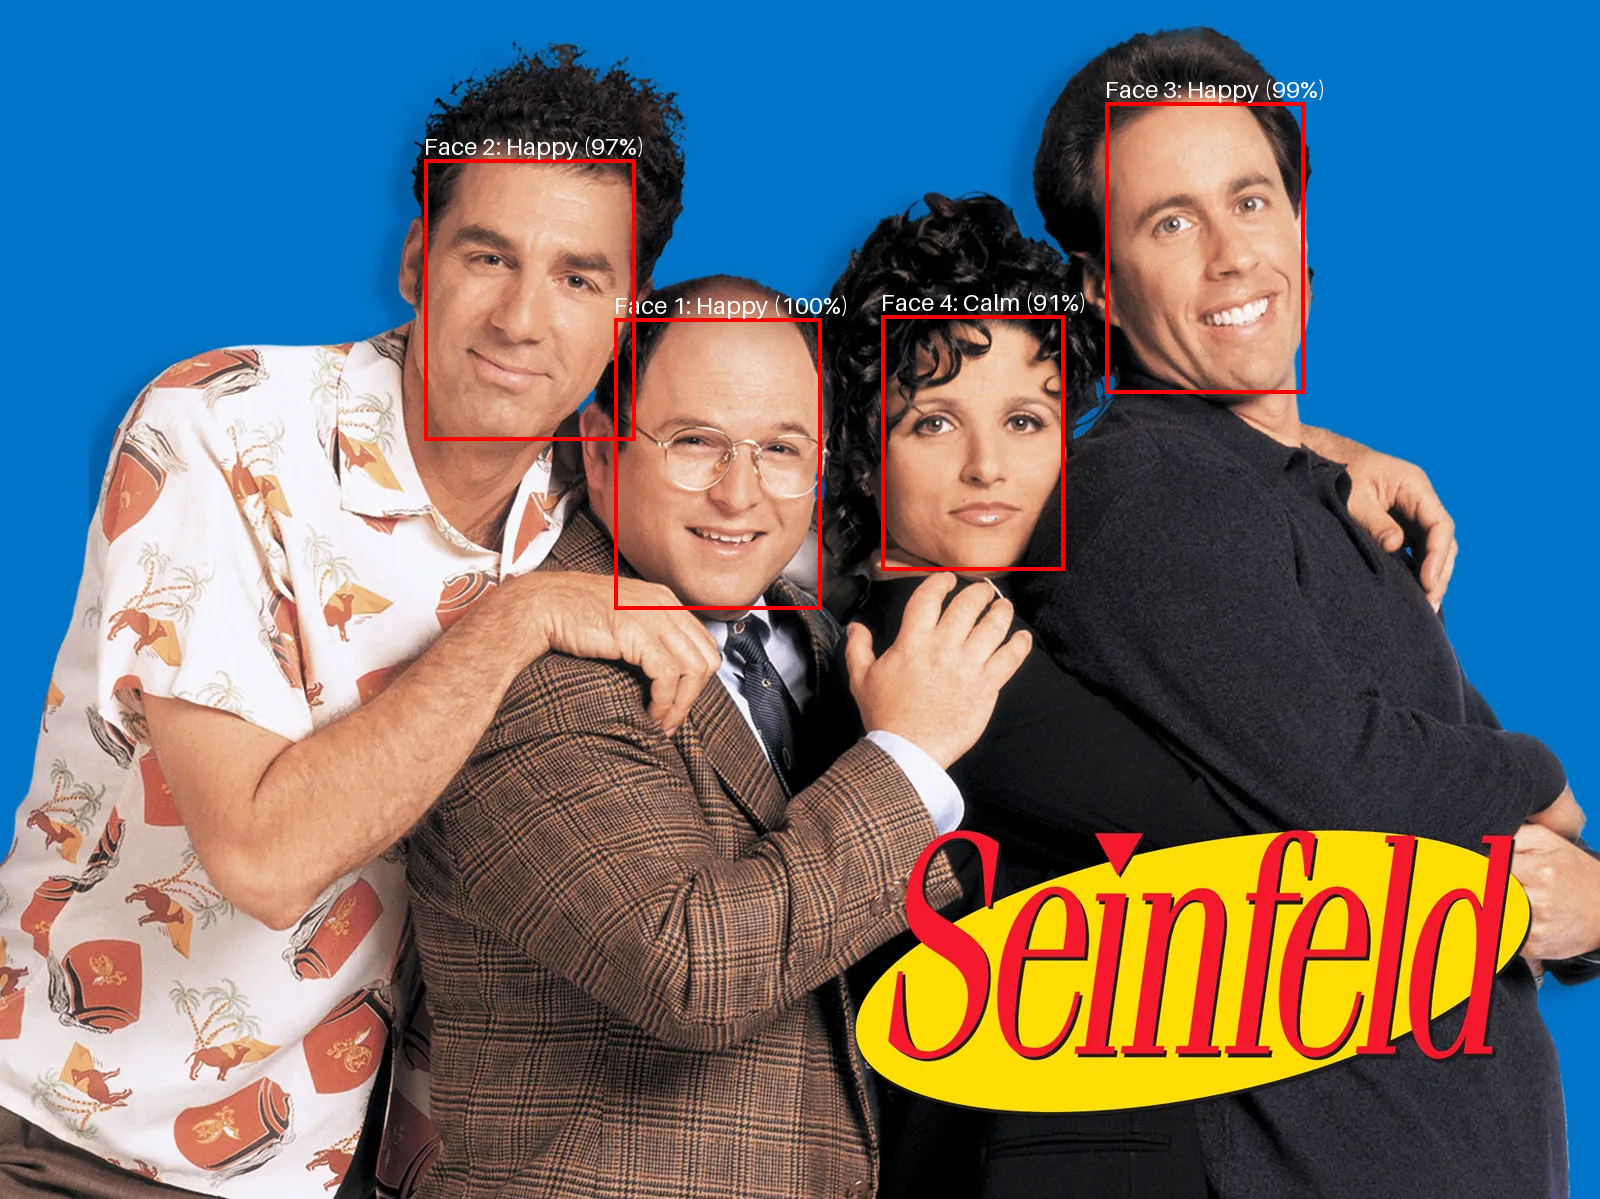

Seinfeld: celebrity recognition


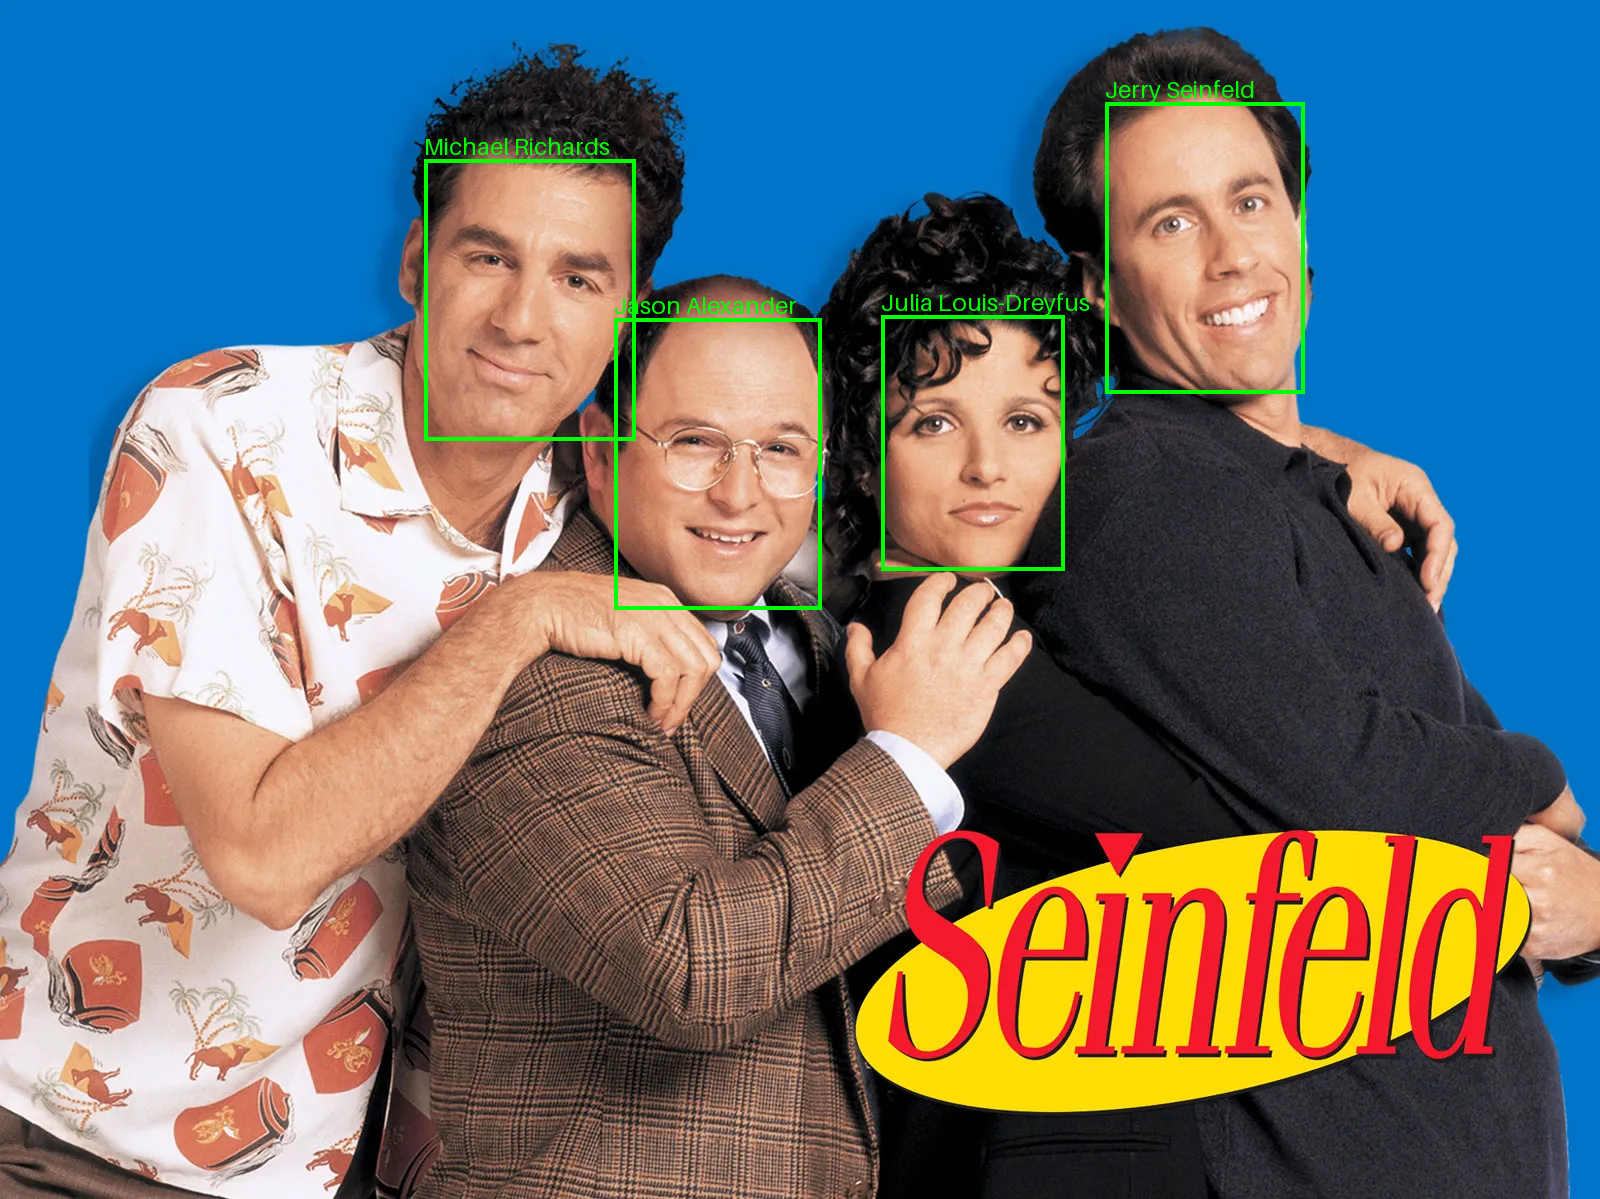

In [52]:
print("Seinfeld: emotion recognition")
print_face_summary(results["seinfeld"])
render_image_analysis(seinfeld_path, results["seinfeld"], annotations=("emotions",))

print("Seinfeld: celebrity recognition")
render_image_analysis(seinfeld_path, results["seinfeld"], annotations=("celebrities",))

## 8. Inspect CloudWatch evidence

CloudWatch Logs provides operational evidence that the deployed application ran. Lambda automatically writes platform messages such as runtime startup and invocation duration, while our code writes an `analysis_complete` message after it stores a result.

This cell filters out the platform noise and reads only the application's completion records created after the uploads. Each record identifies the S3 object that was processed and summarises the labels, faces, text, and celebrity matches. If processing fails, the unfiltered Lambda log stream is also where the exception and stack trace will appear.

Lambda creates its CloudWatch log group lazily when the function first writes logs; deploying the stack alone does not create it. If the group is not available yet, the cell reports that state and tells you what to run next.

In [ ]:
logs = session.client("logs")
log_group = f"/aws/lambda/{FUNCTION}"

try:
    # Filter to this run's structured completion messages, not every Lambda log line.
    events = logs.filter_log_events(
        logGroupName=log_group,
        filterPattern='"analysis_complete"',
        startTime=int(analysis_started_at.timestamp() * 1000),
        limit=10,
    )["events"]
except logs.exceptions.ResourceNotFoundException:
    print(f"CloudWatch log group {log_group} does not exist yet.")
    print("Lambda creates the group on its first invocation. Upload the images above, wait a few seconds, then rerun this cell.")
else:
    if not events:
        print("The log group exists, but no completed analysis log is visible yet. Wait a few seconds, then rerun this cell.")
    else:
        print("Lambda workflow evidence:")
        for event in events:
            payload = event["message"].split("analysis_complete ", 1)[-1]
            evidence = json.loads(payload)
            print(f"Processed: s3://{evidence['bucket']}/{evidence['key']}")
            print("Labels: " + ", ".join(label["name"] for label in evidence["labels"]))
            if evidence.get("text_detections"):
                print("Text: " + ", ".join(text["text"] for text in evidence["text_detections"]))
            if evidence.get("face_count") > 0:
                print(f"Faces: {evidence['face_count']}")
            if evidence.get("celebrity_matches"):
                print("Celebrities: " + ", ".join(match["name"] for match in evidence["celebrity_matches"]))
            print("---")

## What this demo demonstrates

This pipeline combines several managed services into one application without provisioning a server. S3 decouples the upload from processing, Lambda contains the orchestration and data-selection logic, Rekognition supplies trained computer-vision capabilities, DynamoDB stores durable application results, and CloudWatch makes execution observable.

The distinction between the application and the model is important: we designed the event flow, permissions, storage schema, output formatting, and visualisation, but we did not build, train, host, or scale the Rekognition models. In the AWS console, the same flow can be followed by locating the uploaded S3 objects, their DynamoDB items, and the Lambda log group.

## 9. Clean up the AWS resources

When you have finished the demo, tear down the stack to avoid leaving cloud resources in the account. The management script empties the generated S3 bucket before asking SAM and CloudFormation to delete the stack. The `--yes` flag is required because teardown is destructive.

In [15]:
profile_option = f" --profile {PROFILE}" if PROFILE else ""
print("When you have finished the demo, run:")
print(f"cd {DEMO_ROOT} && ./manage_demo.sh --demo 1 --action teardown --yes{profile_option}")

When the demonstration is finished, run:
cd /Users/larryhh/Documents/UWA/CITS5503/demo && ./manage_demo.sh --demo 1 --action teardown --yes
